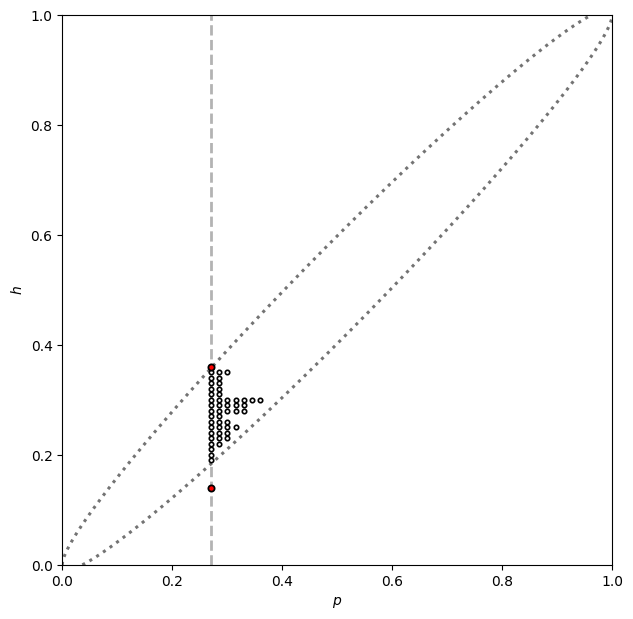

In [1]:
from collections import Counter
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np


# Parameter
n = 100
anzahl = 50
p0 = 0.27
gamma = 0.95
seed = None

rng = np.random.default_rng(seed)
h = rng.binomial(n, p0, size=anzahl) / n

# Randkurven des Neyman-Raums
z = NormalDist().inv_cdf((1 + gamma) / 2)

p = np.linspace(0, 1, 2001)
radius = z * np.sqrt(p * (1 - p) / n)

# Gleiche h-Werte seitlich stapeln
schrittweite = 0.015       # nur für die Darstellung

p_punkte = []
h_punkte = []

for h_wert, vielfachheit in sorted(Counter(h).items()):
    p_punkte.extend(p0 + schrittweite * np.arange(vielfachheit))
    h_punkte.extend([h_wert] * vielfachheit)

p_punkte = np.asarray(p_punkte)
h_punkte = np.asarray(h_punkte)

# Punkte außerhalb des Prognoseintervalls markieren
radius0 = z * np.sqrt(p0 * (1 - p0) / n)
innen = (
    (h_punkte >= p0 - radius0)
    & (h_punkte <= p0 + radius0)
)

# Darstellung
fig, ax = plt.subplots(figsize=(6.4, 6.4))

ax.plot(p, p - radius, ":", color="0.45", linewidth=2.2)
ax.plot(p, p + radius, ":", color="0.45", linewidth=2.2)
ax.axvline(p0, color="0.7", linestyle="--", linewidth=2)

ax.scatter(
    p_punkte[innen],
    h_punkte[innen],
    s=10,
    facecolors="white",
    edgecolors="black",
    linewidths=1.2,
    zorder=3,
)

ax.scatter(
    p_punkte[~innen],
    h_punkte[~innen],
    s=20,
    facecolors="red",
    edgecolors="black",
    linewidths=1.3,
    zorder=4,
)

ax.set(
    xlim=(0, 1),
    ylim=(0, 1),
    xlabel=r"$p$",
    ylabel=r"$h$",
)
ax.set_aspect("equal")

fig.tight_layout()
fig.savefig("Neymanraum.pdf", bbox_inches="tight")
plt.show()